In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/raw/test_dataset.csv')

In [4]:
df.head(10)

,amount,currency,trans_count,trans_sum,trans_mean,trans_max,trans_min,trans_std,hour,day_of_week,isfraud
0,74.80,0,178.0,1296788.80,7285.3300,490129.34,5.18,41613.4600,10,3,0
1,35.54,0,175.0,553853.75,3164.8787,37130.34,1.58,4748.2370,14,4,0
2,180.59,0,165.0,408867.20,2477.9830,18148.14,0.39,2784.7986,0,3,0
3,10.51,0,129.0,280399.60,2173.6401,35244.81,1.15,3786.3496,3,0,0
4,495.80,0,205.0,641381.94,3128.6924,57829.68,0.06,6351.4004,6,3,0
5,60.30,0,147.0,432891.70,2944.8416,38602.20,1.15,4829.3115,22,4,0
6,2384.84,0,122.0,410645.56,3365.9470,41587.75,0.30,5738.9300,5,2,0
7,230.42,0,169.0,538255.56,3184.9440,37907.21,0.30,5304.3047,20,0,0
8,1.29,0,171.0,492543.44,2880.3710,25307.72,1.06,4594.6895,16,1,0
9,293.03,0,106.0,429713.12,4053.8972,32776.28,132.90,6150.1626,9,5,0


In [5]:
df['amount_to_mean_ratio'] = df['amount'] / (df['trans_mean'] + 1e-5)

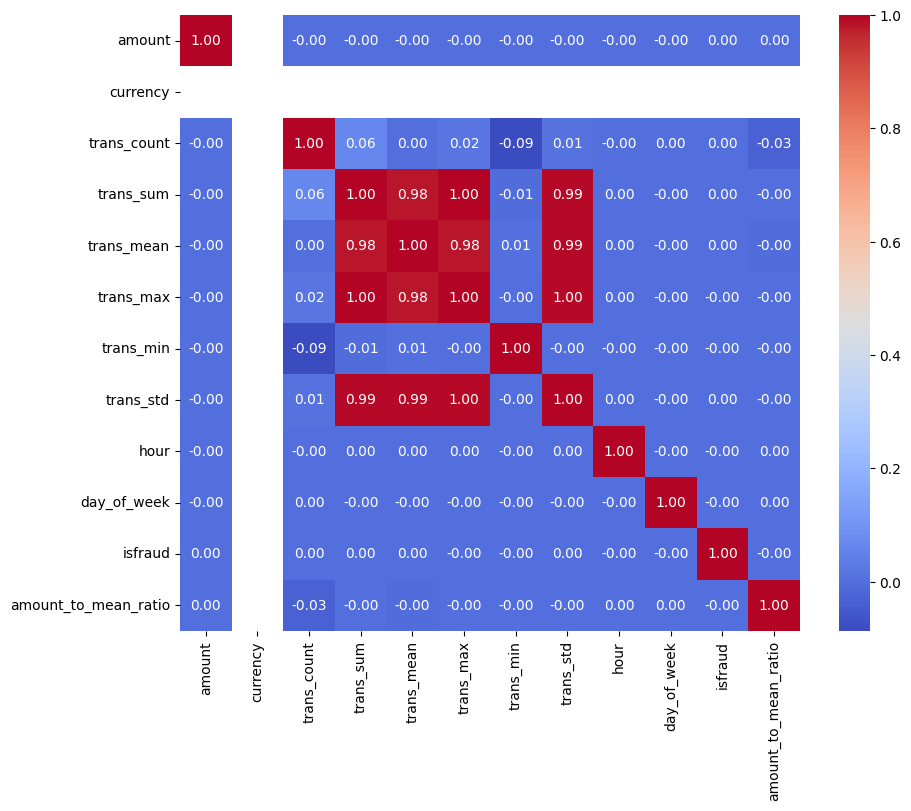

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [7]:
#УДАЛЕНИЕ НЕНУЖНЫХ ПРИЗНАКОВ, ЕСЛИ НАДО - ВОЗВРАЩАЙ
#CURRENCY ВООБЩЕ ВСЕГДА 0 РАВНА БЫЛА
to_drop = ['currency'] # Оставляем агрегаты для ML!
df_new = df.drop(columns=to_drop)

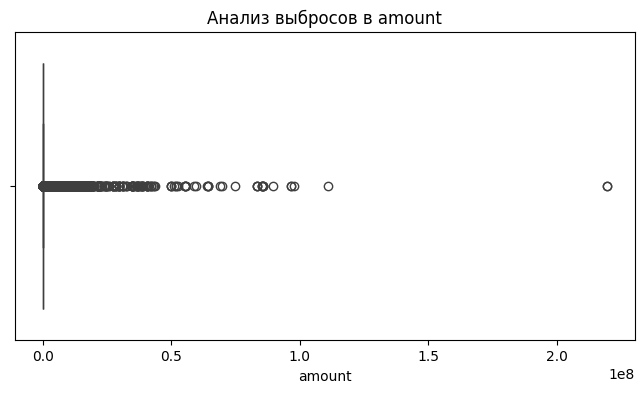

In [8]:
#ПРОВЕДЕМ АНАЛИЗ AMOUNT
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_new['amount'])
plt.title('Анализ выбросов в amount')
plt.show()

In [9]:
top_transactions = df_new.nlargest(70, 'amount')
print(top_transactions[['amount', 'isfraud']])

              amount  isfraud
1356321  219415870.0        0
1852721  219415870.0        0
104783   110742430.0        0
1865782   97641290.0        0
2814389   96688470.0        0
...              ...      ...
361603    35992960.0        0
2767643   35422252.0        0
1243126   34931704.0        0
1299286   34931704.0        0
1799175   34931704.0        0

[70 rows x 2 columns]


In [10]:
#Я ВЫЯСНИЛ, ЧТО В АНОМАЛЬНО БОЛЬШИХ ВЫБРОСАХ ФРОДА МАЛО, ПОЭТОМУ ПОДОБРАЛ ПОРОГ И УБРАЛ ШУМЫ
limit = df_new['amount'].quantile(0.9975)

outliers = df_new[df_new['amount'] > limit]
fraud_in_outliers = outliers['isfraud'].sum()
total_fraud = df_new['isfraud'].sum()

print(f"Всего фрода: {total_fraud}")
print(f"Порог отсечения: {limit:.2f}")
print(f"Будет удалено строк: {len(outliers)} из {len(df_new)}")
print(f"Из них являются фродом: {fraud_in_outliers}")
print(F"Таким образом потеряно {fraud_in_outliers / total_fraud:.5f} - доля всех фродов, что является допустимым")


Всего фрода: 2818
Порог отсечения: 678330.24
Будет удалено строк: 8632 из 3452496
Из них являются фродом: 6
Таким образом потеряно 0.00213 - доля всех фродов, что является допустимым


In [11]:
df_new = df_new[df_new['amount'] <= limit].reset_index(drop=True)

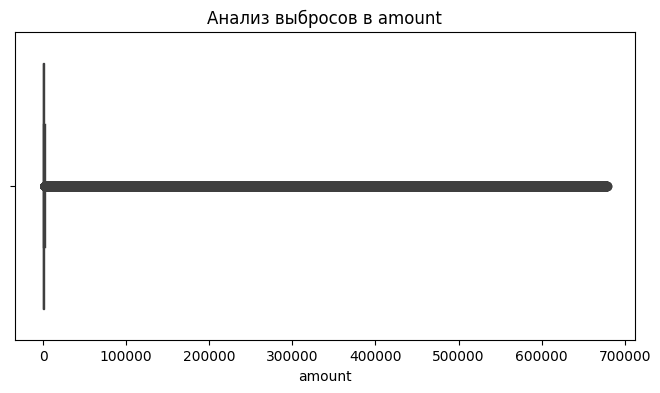

In [12]:
#ПРОВЕДЕМ АНАЛИЗ AMOUNT ЕЩЕ РАЗ
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_new['amount'])
plt.title('Анализ выбросов в amount')
plt.show()

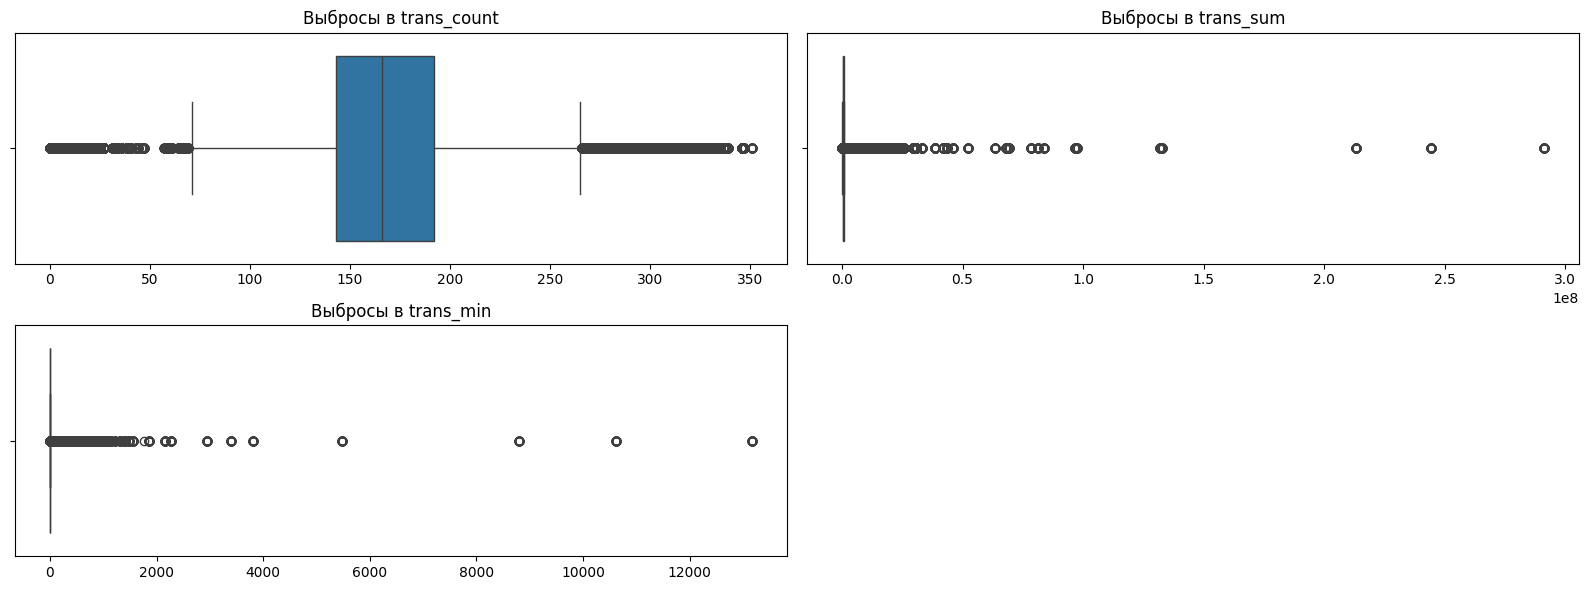

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['trans_count', 'trans_sum', 'trans_min']

num_features = len(numeric_cols)
fig, axes = plt.subplots(nrows=(num_features + 1) // 2, ncols=2, figsize=(16, num_features * 2))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df_new[col], ax=axes[i])
    axes[i].set_title(f'Выбросы в {col}')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Для признака trans_sum обязательно применить логарифмирование np.log1p или использовать RobustScaler или другой масшибировщик, так как у него жеско тяжелый хвост.
я решил не удалять эти выбросы, тк можем полезные переводы выбросить. в крайнем случае аналогоично почисть, как я выше amount чистил

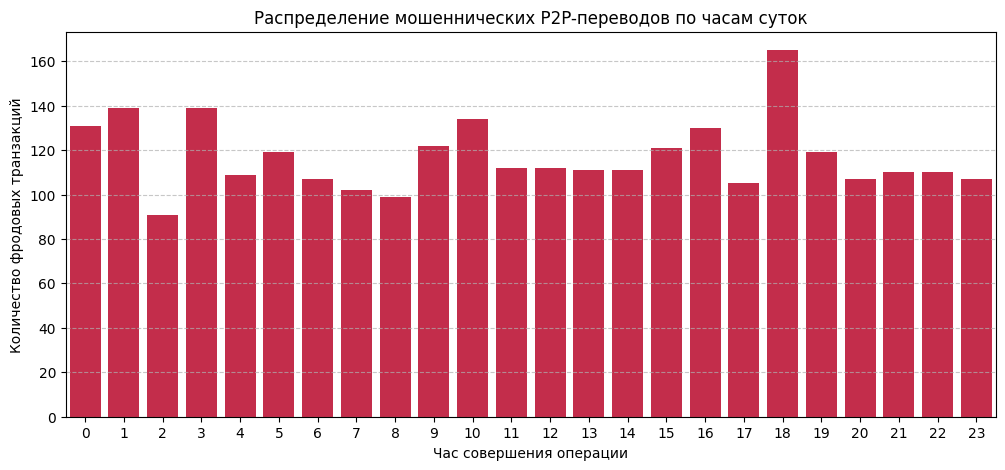

In [14]:
plt.figure(figsize=(12, 5))
# Фильтруем датасет, оставляя только мошеннические операции (isfraud == 1)
sns.countplot(data=df_new[df_new['isfraud'] == 1], x='hour', color='crimson')
plt.title('Распределение мошеннических P2P-переводов по часам суток')
plt.xlabel('Час совершения операции')
plt.ylabel('Количество фродовых транзакций')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

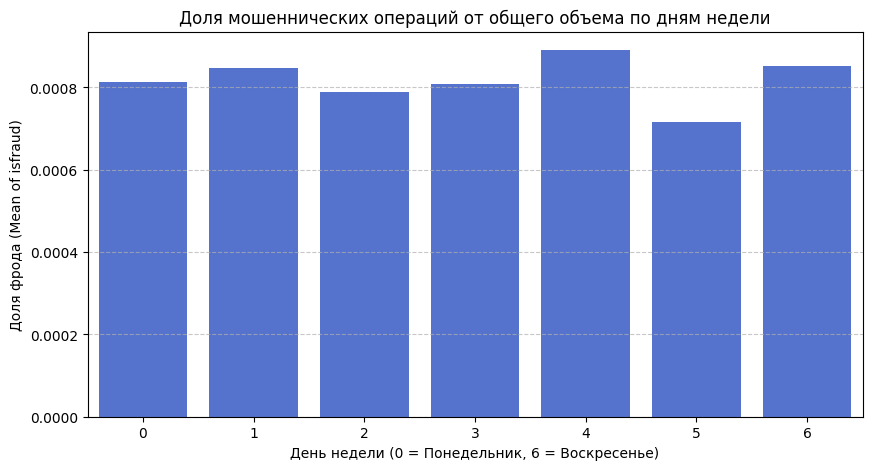

In [15]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_new, x='day_of_week', y='isfraud', color='royalblue', errorbar=None)
plt.title('Доля мошеннических операций от общего объема по дням недели')
plt.xlabel('День недели (0 = Понедельник, 6 = Воскресенье)')
plt.ylabel('Доля фрода (Mean of isfraud)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [16]:
df_new.to_csv('../data/processed/cleaned_dataset.csv', index=False)